In [11]:
!pip install torch torchtext torchvision yfinance scikit-learn matplotlib -q datasets sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.9 MB/s eta 0:00:00


[INFO] Device : cuda

[INFO] Loading dataset …
[INFO] 96,217 pairs loaded ✓
[INFO] Train 76,975  Val 9,621  Test 9,621
[INFO] EN vocab 10,000  FR vocab 10,000
[INFO] Parameters: 15,767,312

[INFO] Training …

Epoch [  1/30]  Train 5.9577  Val 6.0177  BLEU  0.06  TF 0.88  [22s] ✓
Epoch [  2/30]  Train 5.1418  Val 5.9925  BLEU  0.34  TF 0.86  [22s] ✓
Epoch [  3/30]  Train 4.7530  Val 5.8250  BLEU  0.68  TF 0.84  [22s] ✓
Epoch [  4/30]  Train 4.4724  Val 5.7090  BLEU  1.49  TF 0.82  [22s] ✓
Epoch [  5/30]  Train 4.2796  Val 5.5677  BLEU  2.01  TF 0.80  [22s] ✓
Epoch [  6/30]  Train 4.1047  Val 5.4820  BLEU  2.19  TF 0.78  [22s] ✓
Epoch [  7/30]  Train 3.9867  Val 5.3996  BLEU  2.76  TF 0.76  [22s] ✓
Epoch [  8/30]  Train 3.8901  Val 5.3129  BLEU  2.95  TF 0.74  [22s] ✓
Epoch [  9/30]  Train 3.7868  Val 5.3291  BLEU  3.10  TF 0.72  [22s]  (pat 1/5)
Epoch [ 10/30]  Train 3.7240  Val 5.2408  BLEU  3.63  TF 0.70  [22s] ✓
Epoch [ 11/30]  Train 3.6616  Val 5.1977  BLEU  3.87  TF 0.68  [23s] ✓
E

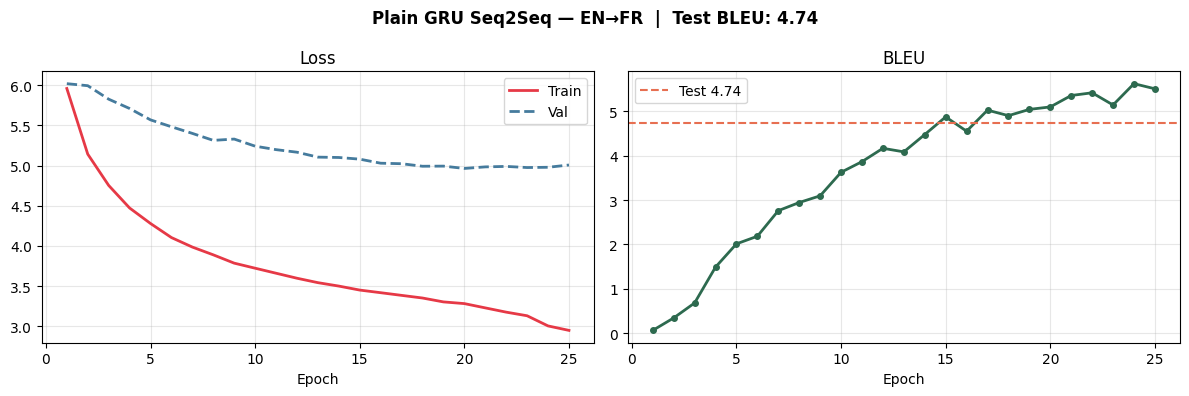

[INFO] Plot saved → gru_plain_results.png


In [15]:
"""
Plain GRU Encoder-Decoder — EN→FR Translation
No attention, no bidirectional encoder, no label smoothing.
"""

import os, re, random, time, collections
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

try:
    from google.colab import userdata
    _tok = userdata.get("Insert Hugging Face Token")
    if _tok: os.environ["Insert Hugging Face Token"] = _tok; print("[INFO] HF_TOKEN loaded ✓")
except Exception:
    pass

try:
    from datasets import load_dataset
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
    from datasets import load_dataset

try:
    import sacrebleu
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"])
    import sacrebleu

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Hyperparameters ──────────────────────────────────────────
MAX_SRC_LEN = 30
MAX_TGT_LEN = 35
MAX_VOCAB   = 10_000
MAX_PAIRS   = 120_000
EMB_DIM     = 256
HID_DIM     = 512
N_LAYERS    = 2
DROPOUT     = 0.3
BATCH_SIZE  = 128
EPOCHS      = 30
LR          = 5e-4
CLIP        = 1.0
PATIENCE    = 5
TF_START    = 0.90
TF_END      = 0.50
TF_DECAY    = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device : {DEVICE}")

# ── Special tokens ───────────────────────────────────────────
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
SPECIALS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

# ── Vocabulary ───────────────────────────────────────────────
class Vocab:
    def __init__(self):
        self.w2i = {t: i for i, t in enumerate(SPECIALS)}
        self.i2w = {i: t for i, t in enumerate(SPECIALS)}
        self.freq = collections.Counter()

    def add(self, tokens): self.freq.update(tokens)

    def build(self, max_vocab):
        for w, _ in self.freq.most_common(max_vocab - len(SPECIALS)):
            i = len(self.w2i); self.w2i[w] = i; self.i2w[i] = w

    def encode(self, tokens):
        return [self.w2i.get(t, UNK_IDX) for t in tokens]

    def decode(self, ids):
        return " ".join(self.i2w.get(i, "<UNK>") for i in ids
                        if self.i2w.get(i) not in SPECIALS)

    def __len__(self): return len(self.w2i)

# ── Text normalisation ───────────────────────────────────────
def normalise(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?])", r" \1", text)
    text = re.sub(r"[^a-zàâäéèêëîïôùûüçœæ' .!?-]", " ", text)
    return re.sub(r"\s+", " ", text).strip().split()

# ── Load data ────────────────────────────────────────────────
print("\n[INFO] Loading dataset …")
pairs = []
try:
    ds = load_dataset("Helsinki-NLP/opus_books", "en-fr", split="train")
    for row in ds:
        en = normalise(row["translation"]["en"])
        fr = normalise(row["translation"]["fr"])
        if 1 < len(en) <= MAX_SRC_LEN and 1 < len(fr) <= MAX_TGT_LEN:
            pairs.append((en, fr))
        if len(pairs) >= MAX_PAIRS: break
    print(f"[INFO] {len(pairs):,} pairs loaded ✓")
except Exception as e:
    print(f"[WARN] {e}")

random.shuffle(pairs)
n = len(pairs)
nv = max(500, int(n * 0.1)); nte = max(500, int(n * 0.1))
train_pairs, val_pairs, test_pairs = pairs[:n-nv-nte], pairs[n-nv-nte:n-nte], pairs[n-nte:]
print(f"[INFO] Train {len(train_pairs):,}  Val {len(val_pairs):,}  Test {len(test_pairs):,}")

# ── Build vocab ───────────────────────────────────────────────
src_vocab, tgt_vocab = Vocab(), Vocab()
for en, fr in train_pairs:
    src_vocab.add(en); tgt_vocab.add(fr)
src_vocab.build(MAX_VOCAB); tgt_vocab.build(MAX_VOCAB)
print(f"[INFO] EN vocab {len(src_vocab):,}  FR vocab {len(tgt_vocab):,}")

# ── Dataset & DataLoader ──────────────────────────────────────
class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.data = [(src_vocab.encode(en),
                      [SOS_IDX] + tgt_vocab.encode(fr) + [EOS_IDX])
                     for en, fr in pairs]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate(batch):
    srcs, tgts = zip(*batch)
    sl = [len(s) for s in srcs]
    sp = torch.zeros(len(batch), max(sl), dtype=torch.long)
    tp = torch.zeros(len(batch), max(len(t) for t in tgts), dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        sp[i, :len(s)] = torch.tensor(s); tp[i, :len(t)] = torch.tensor(t)
    return sp, torch.tensor(sl, dtype=torch.long), tp

train_loader = DataLoader(TranslationDataset(train_pairs), BATCH_SIZE, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(TranslationDataset(val_pairs),   BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(TranslationDataset(test_pairs),  BATCH_SIZE, shuffle=False, collate_fn=collate)

# ── Model ─────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(len(src_vocab), EMB_DIM, padding_idx=PAD_IDX)
        self.gru = nn.GRU(EMB_DIM, HID_DIM, N_LAYERS,
                          batch_first=True, dropout=DROPOUT)
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, src, src_lens):
        x = pack_padded_sequence(self.drop(self.emb(src)), src_lens.cpu(),
                                 batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(x)   # hidden: (N_LAYERS, B, H)
        return hidden


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb  = nn.Embedding(len(tgt_vocab), EMB_DIM, padding_idx=PAD_IDX)
        self.gru  = nn.GRU(EMB_DIM, HID_DIM, N_LAYERS,
                           batch_first=True, dropout=DROPOUT)
        self.fc   = nn.Linear(HID_DIM, len(tgt_vocab))
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, tok, hidden):
        # tok: (B,)  →  (B, 1, EMB)
        out, hidden = self.gru(self.drop(self.emb(tok.unsqueeze(1))), hidden)
        logits = self.fc(out.squeeze(1))   # (B, V)
        return logits, hidden


class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, src, src_lens, tgt, tf_ratio=0.5):
        hidden  = self.encoder(src, src_lens)
        B, T    = tgt.shape
        outputs = torch.zeros(B, T - 1, len(tgt_vocab), device=DEVICE)
        tok     = tgt[:, 0]
        for t in range(1, T):
            logits, hidden = self.decoder(tok, hidden)
            outputs[:, t-1] = logits
            tok = tgt[:, t] if random.random() < tf_ratio else logits.argmax(-1)
        return outputs


model = Seq2Seq().to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] Parameters: {total:,}")

for p in model.parameters():
    if p.dim() > 1: nn.init.xavier_uniform_(p)

# ── Training ──────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimiser = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode="min", factor=0.5, patience=2)

def run_epoch(loader, tf_ratio=0.0, train=False):
    model.train() if train else model.eval()
    total_loss, n_tok = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, src_lens, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            if train: optimiser.zero_grad()
            out = model(src, src_lens, tgt, tf_ratio)
            B, T, V = out.shape
            loss = criterion(out.reshape(B*T, V), tgt[:, 1:].reshape(-1))
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                optimiser.step()
            nt = (tgt[:, 1:] != PAD_IDX).sum().item()
            total_loss += loss.item() * nt; n_tok += nt
    return total_loss / max(n_tok, 1)

def greedy_decode(src_ids):
    model.eval()
    with torch.no_grad():
        src  = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)
        slen = torch.tensor([len(src_ids)])
        hidden = model.encoder(src, slen)
        tok, out = torch.tensor([SOS_IDX], device=DEVICE), []
        for _ in range(MAX_TGT_LEN + 5):
            logits, hidden = model.decoder(tok, hidden)
            tok = logits.argmax(-1)
            if tok.item() == EOS_IDX: break
            out.append(tok.item())
    return out

def bleu(pairs, max_n=2000):
    hyps, refs = [], []
    for en, fr in pairs[:max_n]:
        hyps.append(tgt_vocab.decode(greedy_decode(src_vocab.encode(en))))
        refs.append(" ".join(fr))
    return sacrebleu.corpus_bleu(hyps, [refs], force=True).score

train_losses, val_losses, bleu_scores = [], [], []
best_val, best_state, pat = float("inf"), None, 0

print("\n[INFO] Training …\n")
for epoch in range(1, EPOCHS + 1):
    tf = max(TF_END, TF_START - (TF_START - TF_END) * epoch / TF_DECAY)
    t0 = time.time()
    tl = run_epoch(train_loader, tf_ratio=tf, train=True)
    vl = run_epoch(val_loader)
    train_losses.append(tl); val_losses.append(vl)
    prev_lr = optimiser.param_groups[0]["lr"]
    scheduler.step(vl)
    new_lr  = optimiser.param_groups[0]["lr"]
    lr_note = f"  [LR→{new_lr:.1e}]" if new_lr != prev_lr else ""
    b = bleu(val_pairs)
    bleu_scores.append((epoch, b))
    flag = ""
    if vl < best_val:
        best_val = vl
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        pat = 0; flag = " ✓"
    else:
        pat += 1; flag = f"  (pat {pat}/{PATIENCE})"
    print(f"Epoch [{epoch:>3}/{EPOCHS}]  Train {tl:.4f}  Val {vl:.4f}  "
          f"BLEU {b:5.2f}  TF {tf:.2f}  [{time.time()-t0:.0f}s]{flag}{lr_note}")
    if pat >= PATIENCE:
        print(f"\n[EARLY STOP] Epoch {epoch}"); break

model.load_state_dict(best_state)

# ── Test BLEU ─────────────────────────────────────────────────
test_bleu = bleu(test_pairs)
print(f"\n[TEST BLEU] {test_bleu:.2f}")

# ── Sample translations ───────────────────────────────────────
print(f"\n{'─'*60}")
for en, fr in test_pairs[:8]:
    pred = tgt_vocab.decode(greedy_decode(src_vocab.encode(en)))
    print(f"  SRC : {' '.join(en)}")
    print(f"  REF : {' '.join(fr)}")
    print(f"  HYP : {pred}\n")

# ── Plot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Plain GRU Seq2Seq — EN→FR  |  Test BLEU: {test_bleu:.2f}", fontweight="bold")

ep = range(1, len(train_losses) + 1)
ax1.plot(ep, train_losses, color="#e63946", lw=2, label="Train")
ax1.plot(ep, val_losses,   color="#457b9d", lw=2, ls="--", label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

be, bv = zip(*bleu_scores)
ax2.plot(be, bv, color="#2d6a4f", lw=2, marker="o", ms=4)
ax2.axhline(test_bleu, color="#e76f51", ls="--", lw=1.5, label=f"Test {test_bleu:.2f}")
ax2.set_title("BLEU"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gru_plain_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] Plot saved → gru_plain_results.png")